<a href="https://colab.research.google.com/github/Keshusrm/DeepLearning/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import sys
import torchvision

In [25]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn as nn

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

DATA_DIR = "./data"

# Training dataset
train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

# Test dataset
test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    transform=transform,
    download=True
)

print("Training samples:", len(train_dataset))
print("Test samples    :", len(test_dataset))
print("Dataset location:", DATA_DIR)

Training samples: 60000
Test samples    : 10000
Dataset location: ./data


In [15]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Selected device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Selected device: cpu


In [16]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print("Training batches:", len(train_loader))
print("Test batches    :", len(test_loader))

Training batches: 469
Test batches    : 79


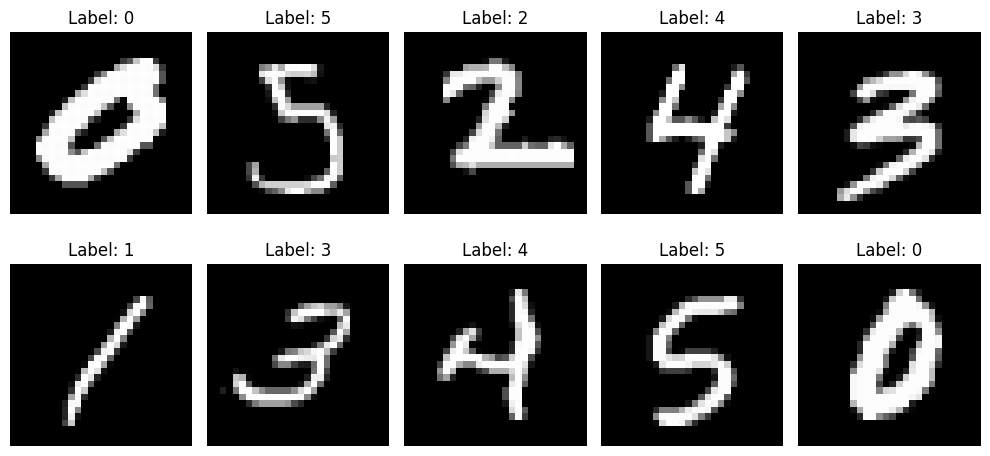

In [17]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()

    # Undo normalization for display
    img = img * 0.3081 + 0.1307
    img = np.clip(img, 0, 1)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
sample_batch = images
print("Before flattening:", sample_batch.shape)

flattened_batch = sample_batch.view(sample_batch.size(0), -1)
print("After flattening :", flattened_batch.shape)

Before flattening: torch.Size([128, 1, 28, 28])
After flattening : torch.Size([128, 784])


In [21]:
class MLP(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = torch.nn.Flatten()
    self.linear_relu_stack = torch.nn.Sequential(
      torch.nn.Linear(28*28, 256),
      torch.nn.ReLU(),
      torch.nn.Linear(256, 128),
      torch.nn.ReLU(),
      torch.nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

model = MLP().to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [22]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total trainable parameters:", total_parameters)

print("\nParameter details:")
for name, parameter in model.named_parameters():
    print(
        f"{name:25s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"count={parameter.numel()}"
    )

Total trainable parameters: 235146

Parameter details:
linear_relu_stack.0.weight shape=(256, 784)         count=200704
linear_relu_stack.0.bias  shape=(256,)             count=256
linear_relu_stack.2.weight shape=(128, 256)         count=32768
linear_relu_stack.2.bias  shape=(128,)             count=128
linear_relu_stack.4.weight shape=(10, 128)          count=1280
linear_relu_stack.4.bias  shape=(10,)              count=10


In [23]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

print("\nFirst image logits:")
print(outputs[0])

print("\nPredicted digit:", outputs[0].argmax().item())
print("Actual digit   :", labels[0].item())

Input shape : torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])

First image logits:
tensor([-0.0954,  0.0776,  0.0183,  0.1222,  0.0757, -0.0724, -0.1394,  0.0366,
         0.0871, -0.0615])

Predicted digit: 3
Actual digit   : 2


In [26]:
# 13. Loss function

criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, labels)

print("Loss for the current batch:", loss.item())

Loss for the current batch: 2.3196909427642822


In [28]:
import torch.optim as optim

LEARNING_RATE = 0.001
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [29]:
optimizer.zero_grad()

outputs = model(images)
loss = criterion(outputs, labels)

loss.backward()

print("Loss:", loss.item())

print("\nGradient information:")
for name, parameter in model.named_parameters():
    if parameter.grad is not None:
        print(
            f"{name:25s} "
            f"shape={tuple(parameter.grad.shape)} "
            f"mean={parameter.grad.mean().item():.6f}"
        )

Loss: 2.3196909427642822

Gradient information:
linear_relu_stack.0.weight shape=(256, 784) mean=0.000032
linear_relu_stack.0.bias  shape=(256,) mean=-0.000005
linear_relu_stack.2.weight shape=(128, 256) mean=-0.000008
linear_relu_stack.2.bias  shape=(128,) mean=-0.000207
linear_relu_stack.4.weight shape=(10, 128) mean=-0.000000
linear_relu_stack.4.bias  shape=(10,) mean=-0.000000


In [30]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 1. Clear previous gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Calculate loss
        loss = criterion(outputs, labels)

        # 4. Backpropagation
        loss.backward()

        # 5. Update parameters
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

In [31]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

In [32]:
# 18. Train the model

EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}%"
    )

Epoch [01/10] | Train Loss: 0.2659 | Train Acc: 92.30% | Test Loss: 0.1247 | Test Acc: 96.19%
Epoch [02/10] | Train Loss: 0.1020 | Train Acc: 96.94% | Test Loss: 0.0897 | Test Acc: 97.07%
Epoch [03/10] | Train Loss: 0.0673 | Train Acc: 97.92% | Test Loss: 0.0820 | Test Acc: 97.46%
Epoch [04/10] | Train Loss: 0.0511 | Train Acc: 98.34% | Test Loss: 0.0730 | Test Acc: 97.87%
Epoch [05/10] | Train Loss: 0.0381 | Train Acc: 98.74% | Test Loss: 0.0758 | Test Acc: 97.71%
Epoch [06/10] | Train Loss: 0.0300 | Train Acc: 99.08% | Test Loss: 0.0751 | Test Acc: 97.81%
Epoch [07/10] | Train Loss: 0.0269 | Train Acc: 99.09% | Test Loss: 0.0699 | Test Acc: 98.10%
Epoch [08/10] | Train Loss: 0.0221 | Train Acc: 99.24% | Test Loss: 0.0676 | Test Acc: 98.15%
Epoch [09/10] | Train Loss: 0.0193 | Train Acc: 99.36% | Test Loss: 0.0848 | Test Acc: 97.60%
Epoch [10/10] | Train Loss: 0.0167 | Train Acc: 99.44% | Test Loss: 0.0888 | Test Acc: 97.77%
